In [3]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import imdb

In [4]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/datasets/npz_utils.py:68: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return RestrictedUnpickler(fp).load()


In [5]:
# num words oznacza ze w treningowym zbiorze danych zostanie zachowanych tylko 10 k slow wystepujacych najczesciej w tym zbiorze danych, slowa 
#wystepujace rzadziej beda pominiete. rozwiazanie te umozliwia prace z wektorem danych o rozmiarze umozliwiajacynm jego przetwarzanie

In [6]:
train_data

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

In [7]:
train_labels

array([1, 0, 0, ..., 0, 1, 0], shape=(25000,))

In [8]:
max([max(sequence) for sequence in train_data])

9999

In [9]:
word_index = imdb.get_word_index()
reverse_word_index = dict(
    [(value,key) for (key, value) in word_index.items()])
decoded_review = ' '.join(
    [reverse_word_index.get(i - 3, '?') for i in train_data[0]])

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [10]:
decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

In [11]:
# przetlumaczona caly kod z numerycznych na tekst - train data [0]

In [12]:
# zamiana na wektory liczb 0 i 1

In [13]:
import numpy as np

In [14]:
def vectorize_sequences(sequences, dimension = 10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1
    return results
x_train = vectorize_sequences(train_data)
x_train

array([[0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.]], shape=(25000, 10000))

In [15]:
x_test = vectorize_sequences(test_data)
x_test

array([[0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.]], shape=(25000, 10000))

In [16]:
train_labels

array([1, 0, 0, ..., 0, 1, 0], shape=(25000,))

In [17]:
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

In [18]:
y_train

array([1., 0., 0., ..., 0., 1., 0.], shape=(25000,), dtype=float32)

In [19]:
from keras import models
from keras import layers

In [186]:
model = keras.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [187]:
model_smaller = keras.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(4, activation='relu'),
    layers.Dense(4, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [228]:
model_bigger = keras.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [143]:
# konfiguracja optymalizatora

In [189]:
from keras import optimizers

In [190]:
model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [191]:
model_smaller.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [229]:
model_bigger.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [230]:
# korzystanie z wlasnych funkcji straty i metryki

In [231]:
from keras import losses
from keras import metrics

In [232]:
# tworzenie zbioru walidacyjnego

In [233]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

In [234]:
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [196]:
# trenowanie modelu

In [197]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7709 - loss: 0.5319 - val_accuracy: 0.8508 - val_loss: 0.4114
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8969 - loss: 0.3272 - val_accuracy: 0.8799 - val_loss: 0.3195
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9175 - loss: 0.2474 - val_accuracy: 0.8816 - val_loss: 0.2941
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9327 - loss: 0.1993 - val_accuracy: 0.8857 - val_loss: 0.2805
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9446 - loss: 0.1667 - val_accuracy: 0.8881 - val_loss: 0.2768
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9532 - loss: 0.1422 - val_accuracy: 0.8866 - val_loss: 0.2861
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9607 - loss: 0.1230 - val_accuracy: 0.8847 - val_loss: 0.2966
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9681 - loss: 0.1043 - val_accuracy: 0.8818 - val_loss

In [198]:
history_smaller = model_smaller.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6297 - loss: 0.6604 - val_accuracy: 0.8225 - val_loss: 0.6219
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7844 - loss: 0.5804 - val_accuracy: 0.7897 - val_loss: 0.5649
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8247 - loss: 0.5286 - val_accuracy: 0.7906 - val_loss: 0.5331
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8561 - loss: 0.4914 - val_accuracy: 0.8226 - val_loss: 0.5086
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8819 - loss: 0.4623 - val_accuracy: 0.8432 - val_loss: 0.4898
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8979 - loss: 0.4390 - val_accuracy: 0.8587 - val_loss: 0.4751
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9146 - loss: 0.4188 - val_accuracy: 0.8409 - val_loss: 0.4707
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9240 - loss: 0.4017 - val_accuracy: 0.8313 - val_loss:

In [235]:
history_bigger = model_bigger.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7303 - loss: 0.5604 - val_accuracy: 0.8585 - val_loss: 0.3572
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8708 - loss: 0.3169 - val_accuracy: 0.8858 - val_loss: 0.2783
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9047 - loss: 0.2351 - val_accuracy: 0.8826 - val_loss: 0.2810
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9314 - loss: 0.1810 - val_accuracy: 0.8874 - val_loss: 0.2752
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9476 - loss: 0.1359 - val_accuracy: 0.8868 - val_loss: 0.3021
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9663 - loss: 0.0993 - val_accuracy: 0.8250 - val_loss: 0.5792
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9643 - loss: 0.1045 - val_accuracy: 0.8829 - val_loss: 0.3125
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9816 - loss: 0.0632 - val_accuracy: 0.8798 - v

In [236]:
history_dict_bigger = history_bigger.history
history_dict_bigger.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [199]:
history_dict_smaller = history_smaller.history
history_dict_smaller.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [200]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [201]:
import matplotlib.pyplot as plt

In [204]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

In [205]:
epochs = range(1, len(acc) + 1)

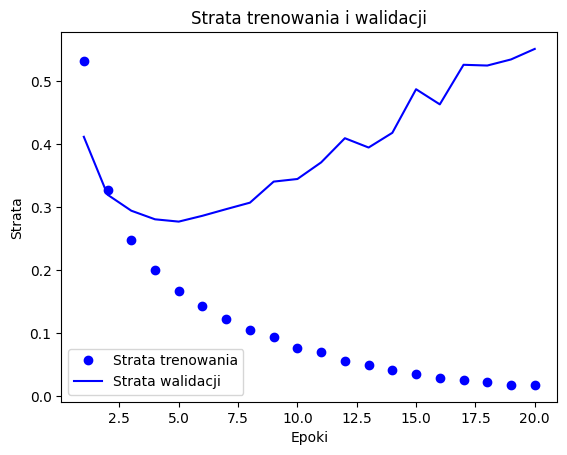

In [206]:
plt.plot(epochs, loss, 'bo', label='Strata trenowania')
plt.plot(epochs, val_loss, 'b', label='Strata walidacji')
plt.title('Strata trenowania i walidacji')
plt.xlabel('Epoki')
plt.ylabel('Strata')
plt.legend()

plt.show()

In [207]:
acc_smaller = history_smaller.history['accuracy']
val_acc_smaller = history_smaller.history['val_accuracy']
loss_smaller = history_smaller.history['loss']
val_loss_smaller = history_smaller.history['val_loss']

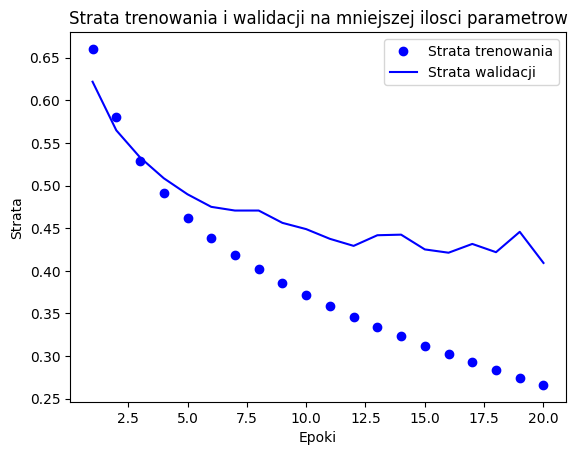

In [209]:
plt.plot(epochs, loss_smaller, 'bo', label='Strata trenowania')
plt.plot(epochs, val_loss_smaller, 'b', label='Strata walidacji')
plt.title('Strata trenowania i walidacji na mniejszej ilosci parametrow')
plt.xlabel('Epoki')
plt.ylabel('Strata')
plt.legend()

plt.show()

Kropki (trening): Błąd stale spada niemal do zera. Oznacza to, że sieć radzi sobie na znanych danych perfekcyjnie.
Linia ciągła (walidacja): Błąd na nowych danych spada tylko do pewnego momentu, a potem gwałtownie rośnie.
Wniosek: Dołek linii walidacyjnej to moment, w którym sieć nauczyła się prawdziwych wzorców. Każda kolejna epoka po tym dołku to psucie modelu — sieć zaczyna uczyć się na pamięć przypadkowego szumu z bazy treningowej.

Treningowa (kropki) leci w dół i walidacyjna (linia) leci razem z nią w dół. Trzymają się blisko siebie. Na koniec obie łagodnieją i wypłaszczają się przy dole wykresu.

In [239]:
acc_bigger = history_bigger.history['accuracy']
val_acc_bigger = history_bigger.history['val_accuracy']
loss_bigger = history_bigger.history['loss']
val_loss_bigger = history_bigger.history['val_loss']

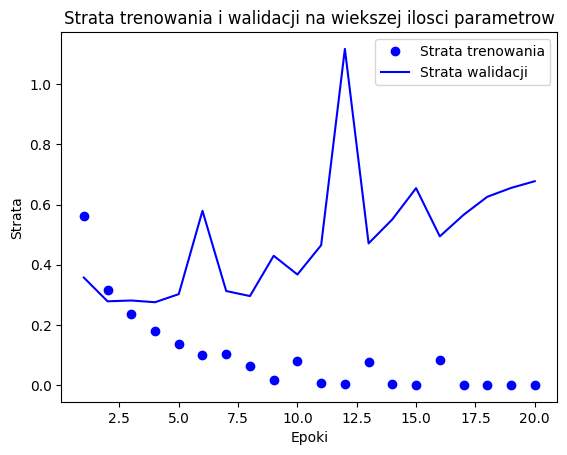

In [240]:
plt.plot(epochs, loss_bigger, 'bo', label='Strata trenowania')
plt.plot(epochs, val_loss_bigger, 'b', label='Strata walidacji')
plt.title('Strata trenowania i walidacji na wiekszej ilosci parametrow')
plt.xlabel('Epoki')
plt.ylabel('Strata')
plt.legend()

plt.show()

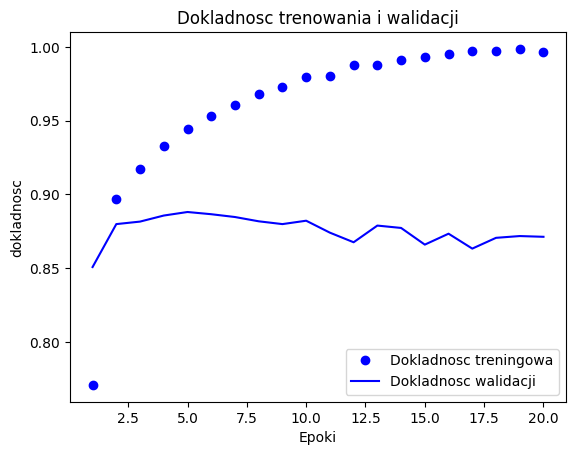

In [224]:
plt.clf()
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

plt.plot(epochs, acc_values, 'bo', label='Dokladnosc treningowa')
plt.plot(epochs, val_acc_values, 'b', label='Dokladnosc walidacji')
plt.title('Dokladnosc trenowania i walidacji')
plt.xlabel('Epoki')
plt.ylabel('dokladnosc')
plt.legend()

plt.show()

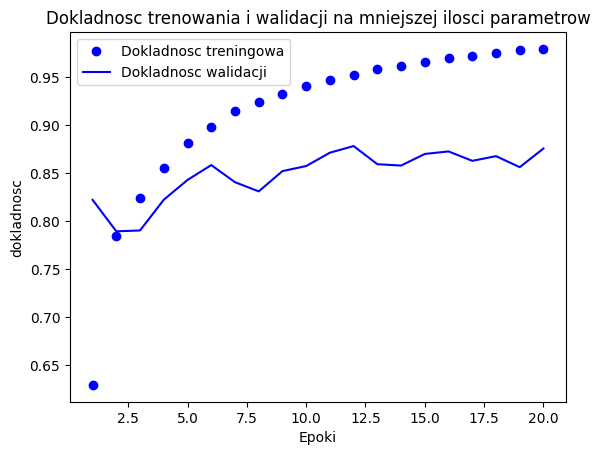

In [223]:
plt.clf()


plt.plot(epochs, acc_smaller, 'bo', label='Dokladnosc treningowa')
plt.plot(epochs, val_acc_smaller, 'b', label='Dokladnosc walidacji')
plt.title('Dokladnosc trenowania i walidacji na mniejszej ilosci parametrow')
plt.xlabel('Epoki')
plt.ylabel('dokladnosc')
plt.legend()

plt.show()

Kropki (trening): W okolicach 10. epoki sieć osiąga niemal 100% skuteczności. Model bezbłędnie kojarzy każdą pojedynczą recenzję, na której się uczył.
Linia ciągła (walidacja): Szczyt osiąga w 3.–4. epoce (≈88%), a potem faluje i lekko opada (86–87%).
Wniosek: Dokładnie potwierdza to wykres straty. Przez kolejne 16 epok marnujesz prąd: model zyskuje kolejne procenty na treningu wyłącznie kosztem „zakuwania na blachę”, nie poprawiając wyników na nowych danych ani o ułamek procenta.

Treningowa leci w górę i walidacyjna leci razem z nią w górę, tuż pod nią. Jeśli trening ma 88%, a walidacja 86% — jest idealnie.

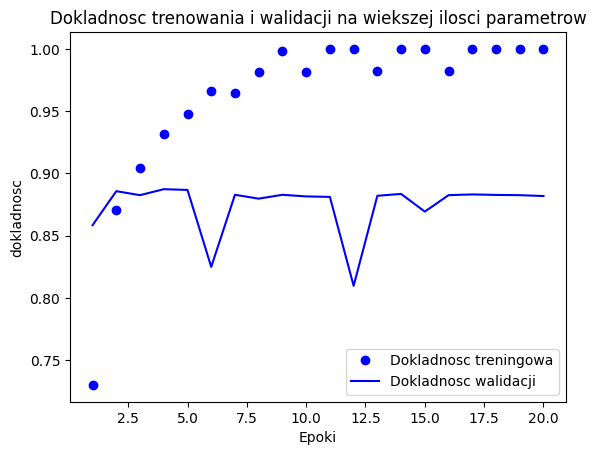

In [241]:
plt.clf()


plt.plot(epochs, acc_bigger, 'bo', label='Dokladnosc treningowa')
plt.plot(epochs, val_acc_bigger, 'b', label='Dokladnosc walidacji')
plt.title('Dokladnosc trenowania i walidacji na wiekszej ilosci parametrow')
plt.xlabel('Epoki')
plt.ylabel('dokladnosc')
plt.legend()

plt.show()

In [212]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer = 'rmsprop',
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8032 - loss: 0.4822
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9004 - loss: 0.2848
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9225 - loss: 0.2222
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9344 - loss: 0.1868
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step - accuracy: 0.8844 - loss: 0.2888


In [225]:
results
# model normalny

[0.2887919545173645, 0.8843600153923035]

Dokładnie tyle wynosił najniższy dołek niebieskiej linii ciągłej (val_loss) na pierwszym wykresie, zanim po 4. epoce zaczęła uciekać w górę do 0.55+.

Dokładnie w tym miejscu niebieska linia (val_accuracy) osiągnęła swój szczyt na drugim wykresie (okolice 0.88).

In [42]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 366us/step


array([[0.16149917],
       [0.9993908 ],
       [0.6675429 ],
       ...,
       [0.06179569],
       [0.04687378],
       [0.3587974 ]], shape=(25000, 1), dtype=float32)

In [227]:
model_smaller = models.Sequential()
model_smaller.add(layers.Dense(4, activation='relu', input_shape=(10000,)))
model_smaller.add(layers.Dense(4, activation='relu'))
model_smaller.add(layers.Dense(1, activation='sigmoid'))

model_smaller.compile(optimizer = 'rmsprop',
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

model_smaller.fit(x_train, y_train, epochs=8, batch_size=512)
results_smaller = model_smaller.evaluate(x_test, y_test)
results_smaller

Epoch 1/8
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7158 - loss: 0.5793
Epoch 2/8
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8760 - loss: 0.4291
Epoch 3/8
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9098 - loss: 0.3210
Epoch 4/8
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9218 - loss: 0.2579
Epoch 5/8
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9292 - loss: 0.2204
Epoch 6/8
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9353 - loss: 0.1962
Epoch 7/8
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9406 - loss: 0.1786
Epoch 8/8
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9460 - loss: 0.1637
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 327us/step - accuracy: 0.8866 - loss: 0.2841


[0.28410542011260986, 0.8866400122642517]

In [243]:
model_bigger = models.Sequential()
model_bigger.add(layers.Dense(512, activation='relu', input_shape=(10000,)))
model_bigger.add(layers.Dense(512, activation='relu'))
model_bigger.add(layers.Dense(1, activation='sigmoid'))

model_bigger.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_bigger.fit(x_train, y_train, epochs=20, batch_size=512)

# 4. Ostateczna ewaluacja na teście
results_bigger = model_bigger.evaluate(x_test, y_test)
print("Model 512:", results_bigger)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7850 - loss: 0.4898
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8884 - loss: 0.2739
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9139 - loss: 0.2164
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9380 - loss: 0.1630
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9539 - loss: 0.1235
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9664 - loss: 0.0942
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9840 - loss: 0.0526
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9879 - loss: 0.0467
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9889 - loss: 0.0444
Epoch 10/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9884 - loss: 0.0525
Epoch 11/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.0032
Epoch 12/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy:

In [244]:
# model z regularyzacja

In [254]:
from tensorflow.keras import regularizers

model_l2 = models.Sequential([
    layers.Dense(16, kernel_regularizer=regularizers.l2(0.001), activation='relu', input_shape=(10000,)),
    layers.Dense(16, kernel_regularizer=regularizers.l2(0.001), activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_l2.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_l2 = model_l2.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val)
)

results_l2 = model_l2.evaluate(x_test, y_test)
results_l2


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7760 - loss: 0.5593 - val_accuracy: 0.8487 - val_loss: 0.4403
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8921 - loss: 0.3630 - val_accuracy: 0.8844 - val_loss: 0.3563
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9188 - loss: 0.2942 - val_accuracy: 0.8775 - val_loss: 0.3516
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9335 - loss: 0.2523 - val_accuracy: 0.8879 - val_loss: 0.3273
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9375 - loss: 0.2342 - val_accuracy: 0.8778 - val_loss: 0.3536
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9485 - loss: 0.2130 - val_accuracy: 0.8759 - val_loss: 0.3632
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9521 - loss: 0.2036 - val_accuracy: 0.8800 - val_loss: 0.3515
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9574 - loss: 0.1910 - val_accuracy: 0.8837 - val_loss

[0.5489914417266846, 0.8461599946022034]

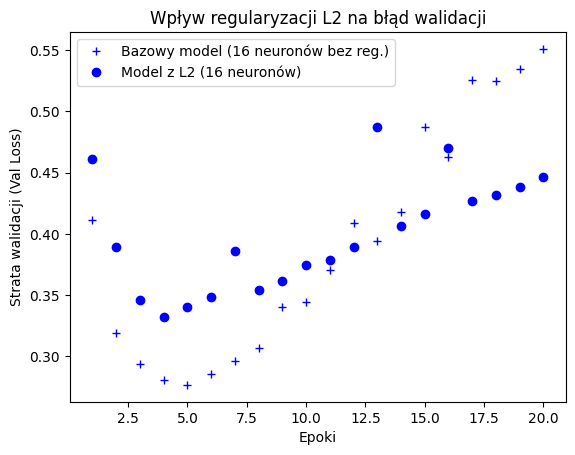

In [253]:
epochs = range(1, 21)
val_loss_base = history_dict['val_loss']
val_loss_l2 = history_l2.history['val_loss']

plt.clf()
plt.plot(epochs, val_loss_base, 'b+', label='Bazowy model (16 neuronów bez reg.)')
plt.plot(epochs, val_loss_l2, 'bo', label='Model z L2 (16 neuronów)')
plt.title('Wpływ regularyzacji L2 na błąd walidacji')
plt.xlabel('Epoki')
plt.ylabel('Strata walidacji (Val Loss)')
plt.legend()
plt.show()

In [255]:
# 1. Dołek dla modelu bazowego
min_loss_base = min(val_loss_base)
best_epoch_base = val_loss_base.index(min_loss_base) + 1

# 2. Dołek dla modelu z L2
min_loss_l2 = min(val_loss_l2)
best_epoch_l2 = val_loss_l2.index(min_loss_l2) + 1

print(f"Model bazowy -> Minimalna strata: {min_loss_base:.4f} w epoce: {best_epoch_base}")
print(f"Model z L2   -> Minimalna strata: {min_loss_l2:.4f} w epoce: {best_epoch_l2}")

Model bazowy -> Minimalna strata: 0.2768 w epoce: 5
Model z L2   -> Minimalna strata: 0.3326 w epoce: 4


In [257]:
# Model z jednoczesną regularyzacją L1 i L2
model_l1_l2 = models.Sequential([
    layers.Dense(16, 
                 kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.0001), 
                 activation='relu', 
                 input_shape=(10000,)),
    layers.Dense(16, 
                 kernel_regularizer=regularizers.l1_l2(l1=0.0001, l2=0.0001), 
                 activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_l1_l2.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_l1_l2 = model_l1_l2.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val)
)

results_l1_l2 = model_l1_l2.evaluate(x_test, y_test)
results_l1_l2

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7660 - loss: 0.6735 - val_accuracy: 0.8609 - val_loss: 0.5157
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8927 - loss: 0.4343 - val_accuracy: 0.8860 - val_loss: 0.4120
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9105 - loss: 0.3574 - val_accuracy: 0.8869 - val_loss: 0.3836
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9191 - loss: 0.3219 - val_accuracy: 0.8866 - val_loss: 0.3741
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9259 - loss: 0.2995 - val_accuracy: 0.8717 - val_loss: 0.4025
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9309 - loss: 0.2878 - val_accuracy: 0.8826 - val_loss: 0.3827
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9349 - loss: 0.2778 - val_accuracy: 0.8853 - val_loss: 0.3761
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9345 - loss: 0.2746 - val_accuracy: 0.8725 - val_loss:

[0.46054911613464355, 0.8682399988174438]

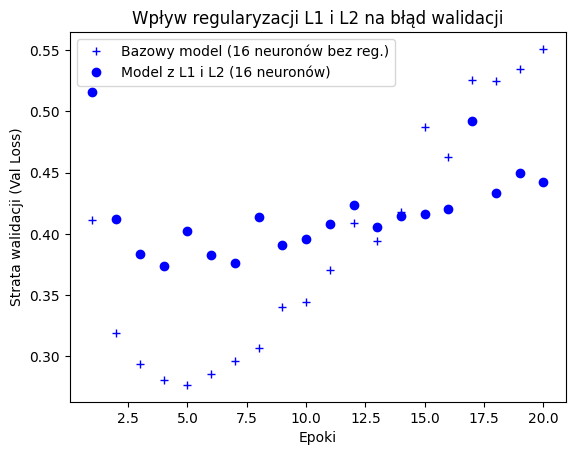

In [258]:
epochs = range(1, 21)
val_loss_base = history_dict['val_loss']
val_loss_l1_l2 = history_l1_l2.history['val_loss']

plt.clf()
plt.plot(epochs, val_loss_base, 'b+', label='Bazowy model (16 neuronów bez reg.)')
plt.plot(epochs, val_loss_l1_l2, 'bo', label='Model z L1 i L2 (16 neuronów)')
plt.title('Wpływ regularyzacji L1 i L2 na błąd walidacji')
plt.xlabel('Epoki')
plt.ylabel('Strata walidacji (Val Loss)')
plt.legend()
plt.show()

In [259]:
model_dropout = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(10000,)),
    layers.Dropout(0.5),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_dropout.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_dropout = model_dropout.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val)
)

results_dp = model_dropout.evaluate(x_test, y_test)
results_dp

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6409 - loss: 0.6336 - val_accuracy: 0.8293 - val_loss: 0.5189
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7619 - loss: 0.5161 - val_accuracy: 0.8695 - val_loss: 0.4013
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8182 - loss: 0.4306 - val_accuracy: 0.8782 - val_loss: 0.3367
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8526 - loss: 0.3739 - val_accuracy: 0.8866 - val_loss: 0.2979
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8831 - loss: 0.3229 - val_accuracy: 0.8889 - val_loss: 0.2812
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8965 - loss: 0.2876 - val_accuracy: 0.8909 - val_loss: 0.2719
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9116 - loss: 0.2557 - val_accuracy: 0.8910 - val_loss: 0.2723
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9250 - loss: 0.2247 - val_accuracy: 0.8901 - val_loss

[0.5501155257225037, 0.8758400082588196]

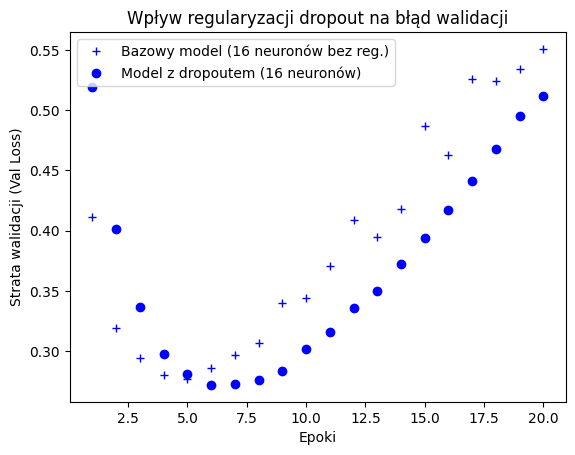

In [260]:
epochs = range(1, 21)
val_loss_base = history_dict['val_loss']
val_loss_dp = history_dropout.history['val_loss']

plt.clf()
plt.plot(epochs, val_loss_base, 'b+', label='Bazowy model (16 neuronów bez reg.)')
plt.plot(epochs, val_loss_dp, 'bo', label='Model z dropoutem (16 neuronów)')
plt.title('Wpływ regularyzacji dropout na błąd walidacji')
plt.xlabel('Epoki')
plt.ylabel('Strata walidacji (Val Loss)')
plt.legend()
plt.show()

### Wnioski – Wpływ regularyzacji Dropout:
1. **Opóźnienie przeuczenia:** Model bazowy zaczyna gwałtownie overfittować już po 4. epoce, podczas gdy Dropout przesuwa optymalny punkt (dołek `val_loss`) na 6.–7. epokę.
2. **Lepsza generalizacja:** W całym przedziale epok 5–20 strata walidacyjna modelu z Dropoutem utrzymuje się znacznie niżej niż w modelu bazowym.
3. **Konkluzja:** Losowe wyłączanie 50% neuronów skutecznie zapobiegło ich ko-adaptacji (*co-adaptation*), działając efektywniej niż regularyzacja wagowa L2.

In [261]:
# zastosowanie early stopping

In [262]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Definicja modelu
model = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 2. Definicja callbacku EarlyStopping
callbacks = [
    EarlyStopping(
        monitor='val_loss',         # śledzimy błąd walidacji
        patience=2,                 # czekaj jeszcze 2 epoki po braku poprawy
        restore_best_weights=True   # kluczowe: przywraca wagi z dołka, a nie z ostatniej epoki
    )
]

# 3. Trening (dajesz np. 30 epok, automat sam przerwie w odpowiednim momencie)
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=30,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=callbacks
)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7655 - loss: 0.5454 - val_accuracy: 0.8224 - val_loss: 0.4456
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8874 - loss: 0.3541 - val_accuracy: 0.8827 - val_loss: 0.3322
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9159 - loss: 0.2630 - val_accuracy: 0.8894 - val_loss: 0.2923
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9297 - loss: 0.2137 - val_accuracy: 0.8906 - val_loss: 0.2792
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9424 - loss: 0.1796 - val_accuracy: 0.8880 - val_loss: 0.2775
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9505 - loss: 0.1527 - val_accuracy: 0.8855 - val_loss: 0.2864
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9589 - loss: 0.1321 - val_accuracy: 0.8858 - val_loss: 0.2858


In [263]:
val_losses = history.history['val_loss']
best_val_loss = min(val_losses)
best_epoch = val_losses.index(best_val_loss) + 1

print(f"Najlepsza epoka: {best_epoch}")
print(f"Najniższy błąd walidacji (dołek): {best_val_loss:.4f}")

Najlepsza epoka: 5
Najniższy błąd walidacji (dołek): 0.2775


In [264]:
results_7 = model.evaluate(x_test, y_test)
print(f"Test Loss: {results_7[0]:.4f} | Test Accuracy: {results_7[1]:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - accuracy: 0.8805 - loss: 0.2942
Test Loss: 0.2942 | Test Accuracy: 0.8805


# zadanie 2

In [43]:
from keras.datasets import reuters

In [44]:
(train_data_2, train_labels_2), (test_data_2, test_labels_2) = reuters.load_data(num_words=10000)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [45]:
len(train_data_2)

8982

In [46]:
len(test_data_2)

2246

In [47]:
train_data_2

array([list([1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]),
       list([1, 3267, 699, 3434, 2295, 56, 2, 7511, 9, 56, 3906, 1073, 81, 5, 1198, 57, 366, 737, 132, 20, 4093, 7, 2, 49, 2295, 2, 1037, 3267, 699, 3434, 8, 7, 10, 241, 16, 855, 129, 231, 783, 5, 4, 587, 2295, 2, 2, 775, 7, 48, 34, 191, 44, 35, 1795, 505, 17, 12]),
       list([1, 53, 12, 284, 15, 14, 272, 26, 53, 959, 32, 818, 15, 14, 272, 26, 39, 684, 70, 11, 14, 12, 3886, 18, 180, 183, 187, 70, 11, 14, 102, 32, 11, 29, 53, 44, 704, 15, 14, 19, 758, 15, 53, 959, 47, 1013, 15, 14, 19, 132, 15, 39, 965, 32, 11, 14, 147, 72, 11, 180, 183, 187, 44, 11, 14, 102, 19, 11, 123, 186, 90, 67, 960, 4, 78, 13, 68, 467, 511, 110,

In [48]:
# dekodowanie indeksow

In [49]:
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data_2[0]])

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


In [50]:
decoded_newswire

'? ? ? said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3'

In [51]:
train_labels_2

array([ 3,  4,  3, ..., 25,  3, 25], shape=(8982,))

In [52]:
train_data_2.shape

(8982,)

In [53]:
def vectorize_sequences(sequences, dimension = 10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1
    return results
x_train_2 = vectorize_sequences(train_data_2)
x_test_2 = vectorize_sequences(test_data_2)

In [54]:
train_labels_2

array([ 3,  4,  3, ..., 25,  3, 25], shape=(8982,))

In [55]:
test_labels_2

array([ 3, 10,  1, ...,  3,  3, 24], shape=(2246,))

In [56]:
from keras.utils import to_categorical

In [57]:
one_hot_train_labels = to_categorical(train_labels_2)
one_hot_test_labels = to_categorical(test_labels_2)

In [58]:
# definicja modelu

In [59]:
model_2 = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax')
])

In [60]:
# kompilacja modelu

In [61]:
model_2.compile(optimizer='rmsprop',
              loss= 'categorical_crossentropy',
              metrics=['accuracy'])

In [62]:
# zbior kontrolny 

In [63]:
x_val_2 = x_train_2[:1000]
partial_x_train_2 = x_train_2[1000:]

In [64]:
partial_x_train_2

array([[0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.]], shape=(7982, 10000))

In [65]:
y_val_2 = one_hot_train_labels[:1000]
partial_y_train_2 = one_hot_train_labels[1000:]

In [66]:
history_2 = model_2.fit(partial_x_train_2,
                        partial_y_train_2,
                        epochs=20,
                        batch_size=512,
                        validation_data=(x_val_2, y_val_2))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4836 - loss: 2.8629 - val_accuracy: 0.6190 - val_loss: 1.9723
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6825 - loss: 1.6014 - val_accuracy: 0.7020 - val_loss: 1.4095
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7478 - loss: 1.1767 - val_accuracy: 0.7340 - val_loss: 1.2093
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7932 - loss: 0.9540 - val_accuracy: 0.7500 - val_loss: 1.1075
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8279 - loss: 0.7913 - val_accuracy: 0.7760 - val_loss: 1.0148
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8562 - loss: 0.6622 - val_accuracy: 0.7900 - val_loss: 0.9751
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8782 - loss: 0.5597 - val_accuracy: 0.8000 - val_loss: 0.9265
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9005 - loss: 0.4743 - val_accuracy: 0.8020 - val_loss

In [67]:
loss_2 = history_2.history['loss']
val_loss_2 = history_2.history['val_loss']
epochs = range(1, len(loss) + 1)

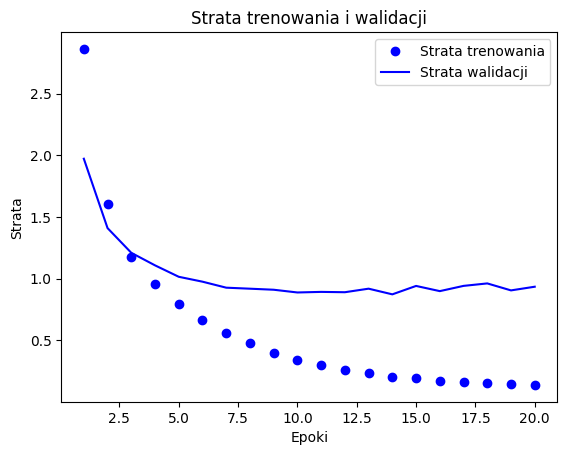

In [68]:
plt.plot(epochs, loss_2, 'bo', label='Strata trenowania')
plt.plot(epochs, val_loss_2, 'b', label='Strata walidacji')
plt.title('Strata trenowania i walidacji')
plt.xlabel('Epoki')
plt.ylabel('Strata')
plt.legend()

plt.show()

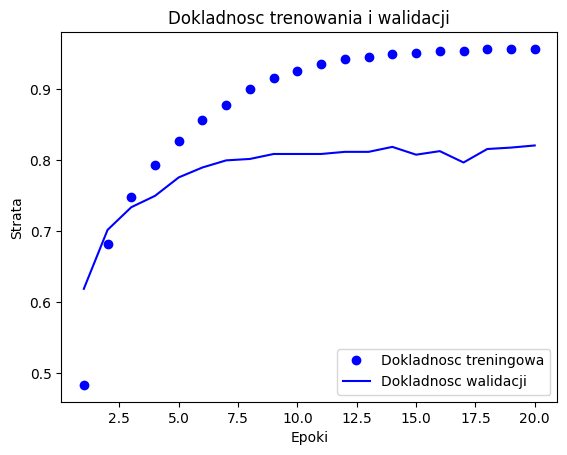

In [69]:
plt.clf()
acc_2 = history_2.history['accuracy']
val_acc_2 = history_2.history['val_accuracy']

plt.plot(epochs, acc_2, 'bo', label='Dokladnosc treningowa')
plt.plot(epochs, val_acc_2, 'b', label='Dokladnosc walidacji')
plt.title('Dokladnosc trenowania i walidacji')
plt.xlabel('Epoki')
plt.ylabel('Strata')
plt.legend()

plt.show()

In [70]:
# tam gdzie val loss jest najmniejszy i val acc najwieksze wybieramy to 

In [71]:
# trenujemy znowu od nowa na 9 epokach

In [72]:
model_2 = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax')
])

model_2.compile(optimizer='rmsprop',
              loss= 'categorical_crossentropy',
              metrics=['accuracy'])

model_2.fit(partial_x_train_2,
            partial_y_train_2,
            epochs=8,
            batch_size=512,
            validation_data=(x_val_2, y_val_2))
results = model_2.evaluate(x_test_2, one_hot_test_labels)

Epoch 1/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5063 - loss: 2.6253 - val_accuracy: 0.6290 - val_loss: 1.7721
Epoch 2/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6912 - loss: 1.4882 - val_accuracy: 0.7200 - val_loss: 1.3452
Epoch 3/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7521 - loss: 1.1384 - val_accuracy: 0.7480 - val_loss: 1.1698
Epoch 4/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7998 - loss: 0.9290 - val_accuracy: 0.7600 - val_loss: 1.0909
Epoch 5/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8351 - loss: 0.7734 - val_accuracy: 0.7880 - val_loss: 0.9839
Epoch 6/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8654 - loss: 0.6387 - val_accuracy: 0.8030 - val_loss: 0.9373
Epoch 7/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8850 - loss: 0.5406 - val_accuracy: 0.7990 - val_loss: 0.9098
Epoch 8/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9050 - loss: 0.4496 - val_accuracy: 0.8050 - val_loss: 0.8980

In [73]:
results

[0.9702884554862976, 0.7791629433631897]

In [74]:
# generowanie przewidywan

In [75]:
predictions_2 = model_2.predict(x_test_2)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step


In [76]:
len(predictions_2)

2246

In [77]:
predictions_2.shape

(2246, 46)

In [78]:
np.argmax(predictions_2[0])

np.int64(3)

In [79]:
# 3 oznacza ze ten artykul nalezy do kategorii 3

In [80]:
# teraz pokazemy dlaczego warto tworzyc odpowiednio duze warstwy 

In [81]:
model_2 = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(4, activation='relu'),
    layers.Dense(46, activation='softmax')
])

model_2.compile(optimizer='rmsprop',
              loss= 'categorical_crossentropy',
              metrics=['accuracy'])

model_2.fit(partial_x_train_2,
            partial_y_train_2,
            epochs=20,
            batch_size=128,
            validation_data=(x_val_2, y_val_2))
results_3 = model_2.evaluate(x_test_2, one_hot_test_labels)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3707 - loss: 2.9402 - val_accuracy: 0.5290 - val_loss: 2.1716
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5942 - loss: 1.7889 - val_accuracy: 0.5940 - val_loss: 1.6017
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6258 - loss: 1.4423 - val_accuracy: 0.6550 - val_loss: 1.4547
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6892 - loss: 1.2466 - val_accuracy: 0.6760 - val_loss: 1.3615
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7241 - loss: 1.1019 - val_accuracy: 0.6900 - val_loss: 1.2994
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7442 - loss: 0.9999 - val_accuracy: 0.7060 - val_loss: 1.2609
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7585 - loss: 0.9245 - val_accuracy: 0.7040 - val_loss: 1.2415
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7727 - loss: 0.8593 - val_accuracy: 0.7060 - val_loss:

In [82]:
results_3

[1.727602243423462, 0.6905609965324402]

In [83]:
# dokladnosc spadla o okolo 8

In [84]:
# teraz sprobujemy dac warsty po 128 

In [85]:
# siec ktora ma jedna warstwe

In [86]:
model_4 = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax')
])

model_4.compile(optimizer='rmsprop',
              loss= 'categorical_crossentropy',
              metrics=['accuracy'])

model_4.fit(partial_x_train_2,
            partial_y_train_2,
            epochs=20,
            batch_size=128,
            validation_data=(x_val_2, y_val_2))
results_4 = model_4.evaluate(x_test_2, one_hot_test_labels)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6332 - loss: 1.8725 - val_accuracy: 0.7300 - val_loss: 1.2210
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7954 - loss: 0.9644 - val_accuracy: 0.8010 - val_loss: 0.9724
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8646 - loss: 0.6744 - val_accuracy: 0.8170 - val_loss: 0.8702
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8993 - loss: 0.4966 - val_accuracy: 0.8230 - val_loss: 0.8224
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9238 - loss: 0.3753 - val_accuracy: 0.8230 - val_loss: 0.8139
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9362 - loss: 0.2979 - val_accuracy: 0.8350 - val_loss: 0.7874
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9437 - loss: 0.2422 - val_accuracy: 0.8320 - val_loss: 0.7957
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9495 - loss: 0.2062 - val_accuracy: 0.8300 - val_loss:

In [87]:
results_4

[1.0770806074142456, 0.790739119052887]

In [88]:
model_5 = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax')
])

model_5.compile(optimizer='rmsprop',
              loss= 'categorical_crossentropy',
              metrics=['accuracy'])

model_5.fit(partial_x_train_2,
            partial_y_train_2,
            epochs=20,
            batch_size=128,
            validation_data=(x_val_2, y_val_2))
results_5 = model_5.evaluate(x_test_2, one_hot_test_labels)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5824 - loss: 1.8527 - val_accuracy: 0.7040 - val_loss: 1.3233
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7512 - loss: 1.0818 - val_accuracy: 0.7570 - val_loss: 1.0991
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8296 - loss: 0.7553 - val_accuracy: 0.7890 - val_loss: 0.9633
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8796 - loss: 0.5338 - val_accuracy: 0.7780 - val_loss: 0.9998
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9117 - loss: 0.3872 - val_accuracy: 0.7940 - val_loss: 1.0208
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9334 - loss: 0.2940 - val_accuracy: 0.7980 - val_loss: 0.9662
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9435 - loss: 0.2399 - val_accuracy: 0.7910 - val_loss: 0.9900
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9513 - loss: 0.1996 - val_accuracy: 0.7870 - val_loss:

In [89]:
results_5

[1.4214054346084595, 0.7724844217300415]

# zadanie 3 

In [90]:
from keras.datasets import boston_housing

In [91]:
(train_data_3, train_targets_3), (test_data_3, test_targets_3) = boston_housing.load_data()

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


In [92]:
train_data_3.shape

(404, 13)

In [93]:
test_data_3.shape

(102, 13)

In [94]:
train_targets_3

array([15.2, 42.3, 50. , 21.1, 17.7, 18.5, 11.3, 15.6, 15.6, 14.4, 12.1,
       17.9, 23.1, 19.9, 15.7,  8.8, 50. , 22.5, 24.1, 27.5, 10.9, 30.8,
       32.9, 24. , 18.5, 13.3, 22.9, 34.7, 16.6, 17.5, 22.3, 16.1, 14.9,
       23.1, 34.9, 25. , 13.9, 13.1, 20.4, 20. , 15.2, 24.7, 22.2, 16.7,
       12.7, 15.6, 18.4, 21. , 30.1, 15.1, 18.7,  9.6, 31.5, 24.8, 19.1,
       22. , 14.5, 11. , 32. , 29.4, 20.3, 24.4, 14.6, 19.5, 14.1, 14.3,
       15.6, 10.5,  6.3, 19.3, 19.3, 13.4, 36.4, 17.8, 13.5, 16.5,  8.3,
       14.3, 16. , 13.4, 28.6, 43.5, 20.2, 22. , 23. , 20.7, 12.5, 48.5,
       14.6, 13.4, 23.7, 50. , 21.7, 39.8, 38.7, 22.2, 34.9, 22.5, 31.1,
       28.7, 46. , 41.7, 21. , 26.6, 15. , 24.4, 13.3, 21.2, 11.7, 21.7,
       19.4, 50. , 22.8, 19.7, 24.7, 36.2, 14.2, 18.9, 18.3, 20.6, 24.6,
       18.2,  8.7, 44. , 10.4, 13.2, 21.2, 37. , 30.7, 22.9, 20. , 19.3,
       31.7, 32. , 23.1, 18.8, 10.9, 50. , 19.6,  5. , 14.4, 19.8, 13.8,
       19.6, 23.9, 24.5, 25. , 19.9, 17.2, 24.6, 13

In [95]:
import sklearn 
from sklearn.preprocessing import StandardScaler

In [96]:
scaler = StandardScaler()
scaled_train_data = scaler.fit_transform(train_data_3)
scaled_test_data = scaler.transform(test_data_3)

In [97]:
def build_model():
    model =models.Sequential([
        layers.Input(shape=(train_data_3.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)])

    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model

In [98]:
# robimy teraz k skladowa walidacje krzyzowa 
# dzielimy zbior treningowy na 4 foldy i wyciagamy mae z kazdego i dzielimy przez ilosc foldow i to bedzie nasz sredni blad

In [99]:
k = 4
num_val_samples = len(train_data_3) // k 
num_epochs = 100
all_scores = []
for i in range(k):
    print('processing fold #', i)
    val_data = scaled_train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets_3[i * num_val_samples: (i + 1) * num_val_samples]

    partial_train_data = np.concatenate(
    [scaled_train_data[:i * num_val_samples],
    scaled_train_data[(i + 1) * num_val_samples:]], axis=0)

    partial_train_targets = np.concatenate(
    [train_targets_3[:i * num_val_samples],
    train_targets_3[(i + 1) * num_val_samples:]], axis=0)

    model_6 = build_model()
    model_6.fit(partial_train_data, partial_train_targets, epochs = num_epochs, batch_size = 1, verbose = 0)
    val_mse, val_mae = model_6.evaluate(val_data, val_targets, verbose=0)
    all_scores.append(val_mae)
    
all_scores

processing fold # 0
processing fold # 1
processing fold # 2
processing fold # 3


[1.8709479570388794, 2.273076057434082, 2.5986578464508057, 2.267014980316162]

In [100]:
all_mae_histories = [] 
num_epochs = 500
for i in range(k):
    print('processing fold #', i)
    val_data = scaled_train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets_3[i * num_val_samples: (i + 1) * num_val_samples]

    partial_train_data = np.concatenate(
    [scaled_train_data[:i * num_val_samples],
    scaled_train_data[(i + 1) * num_val_samples:]], axis=0)

    partial_train_targets = np.concatenate(
    [train_targets_3[:i * num_val_samples],
    train_targets_3[(i + 1) * num_val_samples:]], axis=0)

    model_6 = build_model()
    
    history = model_6.fit(
        partial_train_data, 
        partial_train_targets,
        validation_data=(val_data, val_targets),
        epochs=num_epochs, 
        batch_size=16, 
        verbose=0
    )
    
    mae_history = history.history['val_mae']
    all_mae_histories.append(mae_history)

    
avg_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]
avg_mae_history

processing fold # 0
processing fold # 1
processing fold # 2
processing fold # 3


[np.float64(19.590138912200928),
 np.float64(16.278587341308594),
 np.float64(12.114758729934692),
 np.float64(8.276715159416199),
 np.float64(6.017725229263306),
 np.float64(4.9160497188568115),
 np.float64(4.330265820026398),
 np.float64(3.8905256390571594),
 np.float64(3.5953282713890076),
 np.float64(3.428263008594513),
 np.float64(3.3069857954978943),
 np.float64(3.1479607224464417),
 np.float64(3.0295711755752563),
 np.float64(2.928914725780487),
 np.float64(2.8406739830970764),
 np.float64(2.769920825958252),
 np.float64(2.7415048480033875),
 np.float64(2.7126161456108093),
 np.float64(2.690152108669281),
 np.float64(2.643759310245514),
 np.float64(2.5844770669937134),
 np.float64(2.536124527454376),
 np.float64(2.5302238762378693),
 np.float64(2.6411129236221313),
 np.float64(2.4932605624198914),
 np.float64(2.587526500225067),
 np.float64(2.488662600517273),
 np.float64(2.5031051635742188),
 np.float64(2.4288797080516815),
 np.float64(2.5259307622909546),
 np.float64(2.5134194

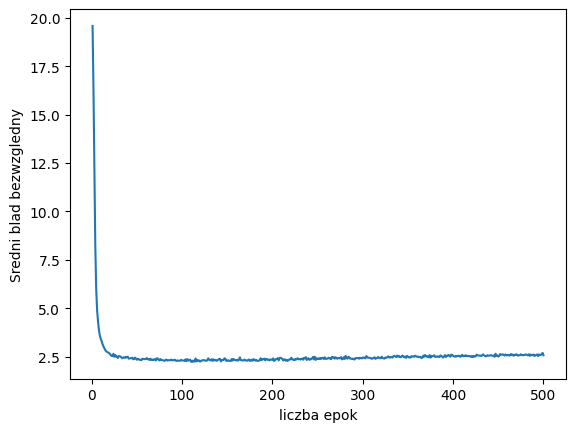

In [101]:
plt.plot(range(1, len(avg_mae_history) + 1), avg_mae_history)
plt.xlabel('liczba epok')
plt.ylabel('Sredni blad bezwzgledny')
plt.show()

In [102]:
def smooth_curve(points, factor =0.9):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

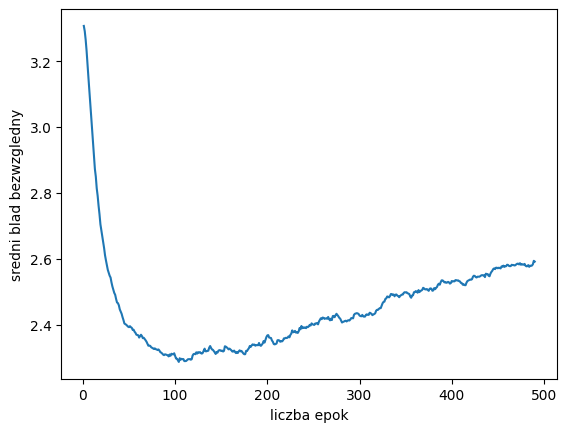

In [103]:
smooth_mae_history = smooth_curve(avg_mae_history[10:])

plt.plot(range(1, len(smooth_mae_history) + 1), smooth_mae_history)
plt.xlabel('liczba epok')
plt.ylabel('sredni blad bezwzgledny')
plt.show()

In [104]:
model = build_model()
model.fit(scaled_train_data, train_targets_3, epochs = 85, batch_size=16, verbose = 0)

test_mse_score, test_mae_score = model.evaluate(scaled_test_data, test_targets_3)
test_mae_score

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.1552 - mae: 2.7071


2.7070960998535156

# testowanie walidacji na odlozonych danych

In [105]:
# 1. Tworzymy przykładowe dane (15 000 próbek)
data = np.random.randn(15000, 10)
targets = np.random.randint(0, 2, size=(15000,))


In [106]:
data.shape

(15000, 10)

In [107]:
targets

array([0, 0, 1, ..., 0, 1, 1], shape=(15000,))

In [108]:
num_validation_samples

NameError: name 'num_validation_samples' is not defined

In [ ]:
indices = np.arange(len(data))
indices

In [ ]:
np.random.shuffle(indices)

In [ ]:
data = data[indices]
data

In [ ]:
targets = targets[indices]
targets

In [ ]:
validation_data_4 = data[9000:12000]
validation_targets_4 = targets[9000:12000]
test_data_4 = data[12000:]
test_targets_4 = targets[12000:]

In [ ]:
training_data_4 = data[:9000]
training_targets_4 = targets[:9000]

In [ ]:
model_7 = models.Sequential([
    layers.Input(shape=(10,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
#sigmoid bo jest to klasyfikacja i wyrzuca liczby 0 lub 1

In [ ]:
model_7.compile(
    optimizer='rmsprop',          # algorytm aktualizacji wag (np. rmsprop lub adam)
    loss='binary_crossentropy',   # funkcja straty (dla klasyfikacji binarnej)
    metrics=['accuracy']          # metryka czytelna dla człowieka
)

In [ ]:
history_7 = model_7.fit(
    training_data,
    training_targets,
    epochs=20,
    batch_size=128,
    validation_data=(validation_data_4, validation_targets_4)
)

In [ ]:
val_loss_7 = history_7.history['val_loss']
loss_7 = history_7.history['loss']

plt.plot(loss, label='Strata treningowa')
plt.plot(val_loss, label='Strata walidacyjna')
plt.legend()
plt.show()

# Overfitting poznajesz po rozjeździe dwóch krzywych: strata treningowa (loss) nadal spada w dół, a strata walidacyjna (val_loss) zaczyna odbijać w górę. Model uczy się szumu i kucia danych na pamięć zamiast ogólnych reguł.

In [ ]:
import numpy as np

best_epoch = np.argmin(val_loss_7) + 1
print(f"Najlepszy punkt odcięcia to epoka numer: {best_epoch}")
print(f"Minimalny val_loss: {min(val_loss):.4f}")

In [ ]:
final_model = models.Sequential([
    layers.Input(shape=(10,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
final_model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
final_model.fit(
    np.concatenate([training_data_4, validation_data_4]),
    np.concatenate([training_targets_4, validation_targets_4]),
    epochs=20,
    batch_size=128,
    verbose=0
)

# Do ok. 100–120 epoki: Obie linie spadają. Model uczy się prawdziwych, ogólnych wzorców z danych.

# Okolice 100–158 epoki (Dolina): Osiągasz sweet spot. W 158. epoce błąd walidacyjny wynosi minimum (10.0458).

# Powyżej 160 epoki: Czyste przeuczenie. Niebieska linia (trening) dalej spada do ~1.0, a pomarańczowa (walidacja) leci z powrotem w górę aż do ~17.5. Każda epoka po 158. tylko psuła model na nowych danych.

# Dokładnie tak. Minimum val_loss to Twój jedyny punkt docelowy.

# Wyznacza on optymalną liczbę epok:

# Przed tym punktem: model jest niedouczony (underfitting) — wciąż może nauczyć się przydatnych zależności.

# W tym punkcie: maksymalna zdolność generalizacji — model najlepiej radzi sobie z nieznanymi danymi.

# Po tym punkcie: przeuczenie (overfitting) — błąd na nowych danych rośnie, bo sieć zaczyna uczyć się szumu na pamięć.

In [ ]:
test_loss, test_acc = final_model.evaluate(test_data_4, test_targets_4)
print(f"Błąd testowy: {test_loss:.4f} | Dokładność testowa: {test_acc:.4f}")